# Advanced Analytics & Risk Metrics

## Bluestock Mutual Fund Analytics

This notebook performs advanced financial analytics on the mutual fund dataset, including:

- Historical Value at Risk (VaR)
- Conditional Value at Risk (CVaR)
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation Engine
- Sector Concentration (HHI)
- Business Insights

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
# Load 

nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv",
    parse_dates=["date"]
)
performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv",
    parse_dates=["transaction_date"]
)
portfolio = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv",
    parse_dates=["portfolio_date"]
)

In [3]:
print("NAV History:", nav.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

NAV History: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)


In [4]:
display(nav.head())
display(performance.head())
display(transactions.head())
display(portfolio.head())

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [5]:
# Sort NAV data by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Daily return for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
risk_metrics = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(risk_metrics)

In [7]:
var_cvar = var_cvar.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

var_cvar = var_cvar[
    ["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]
]

var_cvar.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [9]:
var_cvar = var_cvar.sort_values("VaR_95")

var_cvar.head(40)

,amfi_code,scheme_name,VaR_95,CVaR_95
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [10]:
var_cvar.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


## Historical VaR & CVaR Analysis

- Historical Value at Risk (VaR 95%) estimates the maximum expected daily loss at a 95% confidence level based on historical returns.
- Conditional Value at Risk (CVaR) measures the average loss on days when returns fall below the VaR threshold, providing insight into tail risk.
- Funds with more negative VaR and CVaR values exhibit greater downside risk.
- Comparing these metrics across all schemes helps identify funds with higher exposure to extreme market movements.

In [11]:
# Calculate rolling 90-day Sharpe Ratio

rolling_sharpe = {}

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    returns = group["daily_return"]

    sharpe = (
        returns.rolling(90).mean()
        / returns.rolling(90).std()
    ) * np.sqrt(252)

    group["rolling_sharpe"] = sharpe

    rolling_sharpe[code] = group

In [12]:
top5 = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(5)
)

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,0.99,0.91,1.55,16.0,-33.15,49046,1.52,5,Moderately High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
37,149322,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,Large Cap,Regular,11.96,12.82,12.35,11.00,1.82,0.91,0.92,1.63,14.0,-21.70,41828,1.54,5,Moderate
32,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,Regular,16.30,15.61,15.86,14.49,1.12,0.92,0.82,1.21,19.0,-13.43,41728,1.51,5,High


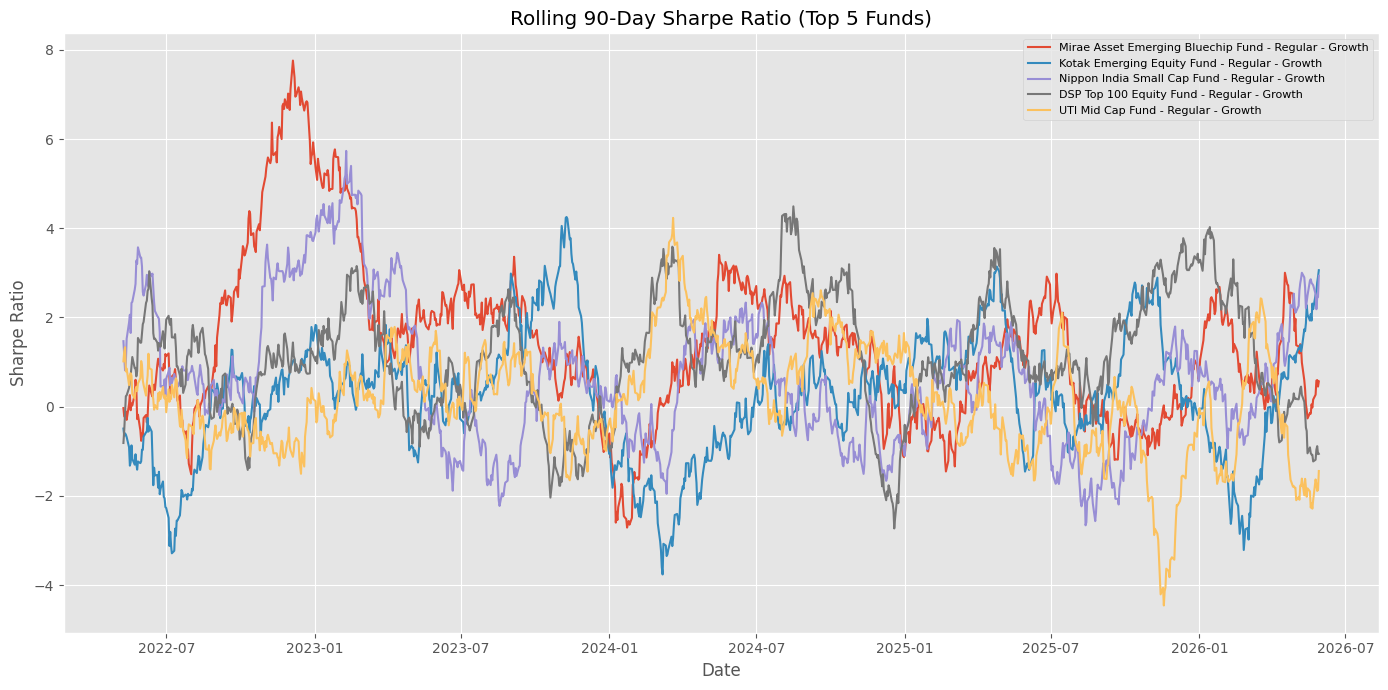

In [13]:
plt.figure(figsize=(14, 7))

for _, row in top5.iterrows():

    code = row["amfi_code"]

    scheme = row["scheme_name"]

    df = rolling_sharpe[code]

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    "../charts/risk/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

## Rolling Sharpe Ratio Analysis

- A higher rolling Sharpe ratio indicates better risk-adjusted performance.
- Positive Sharpe values suggest returns exceeded the risk-free benchmark after adjusting for volatility.
- Large fluctuations indicate periods of unstable performance.
- Comparing the top AUM funds helps identify which maintained consistent risk-adjusted returns over time.

In [14]:
# Keep only SIP transactions
sip = transactions[
    transactions["transaction_type"].str.lower() == "sip"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [15]:
# First investment year for every investor
first_year = (
    sip.groupby("investor_id")["transaction_date"]
       .min()
       .dt.year
       .rename("cohort_year")
)

sip = sip.merge(
    first_year,
    on="investor_id"
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV003054,2024-01-07,120843,Sip,6158,Telangana,Hyderabad,T30,56+,Female,77.1,Cheque,Verified,2024
2,INV003054,2024-02-17,118634,Sip,806,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024
3,INV003054,2024-09-13,118634,Sip,9863,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024
4,INV003054,2024-09-19,101208,Sip,6110,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024


In [16]:
cohort_summary = (
    sip.groupby("cohort_year")
       .agg(
           avg_sip_amount=("amount_inr", "mean"),
           total_invested=("amount_inr", "sum")
       )
       .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,10986.861803,212189262
1,2025,12516.697270,5044229


In [17]:
top_fund = (
    sip.groupby(["cohort_year", "amfi_code"])
       .size()
       .reset_index(name="sip_count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "sip_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund = top_fund.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund = top_fund[
    ["cohort_year", "scheme_name"]
]

top_fund.head()

,cohort_year,scheme_name
0,2024,ABSL Small Cap Fund - Regular - Growth
1,2025,SBI Small Cap Fund - Direct Plan - Growth


In [18]:
cohort_analysis = cohort_summary.merge(
    top_fund,
    on="cohort_year"
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,10986.861803,212189262,ABSL Small Cap Fund - Regular - Growth
1,2025,12516.697270,5044229,SBI Small Cap Fund - Direct Plan - Growth


In [19]:
cohort_analysis.to_csv(
    "../outputs/cohort_analysis.csv",
    index=False
)

print("Cohort analysis saved successfully!")

Cohort analysis saved successfully!


## Investor Cohort Analysis

- Investors are grouped by the year of their first SIP investment.
- The analysis compares average SIP amount and total invested across different cohorts.
- The most preferred mutual fund for each cohort is identified based on the highest number of SIP transactions.
- This helps understand how investor behavior changes over time and which schemes attract new investors.

In [20]:
# Count SIP transactions for each investor
sip_counts = (
    sip.groupby("investor_id")
       .size()
)

eligible_investors = sip_counts[
    sip_counts >= 6
].index

eligible = sip[
    sip["investor_id"].isin(eligible_investors)
].copy()

eligible.shape

(9679, 14)

In [21]:
eligible = eligible.sort_values(
    ["investor_id", "transaction_date"]
)

eligible["gap_days"] = (
    eligible.groupby("investor_id")["transaction_date"]
            .diff()
            .dt.days
)

eligible.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
10979,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
10980,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
10981,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
10982,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
10983,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0
10984,INV000004,2025-05-17,119599,Sip,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,49.0
15460,INV000008,2024-05-27,101206,Sip,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,NaN
15461,INV000008,2024-06-23,102887,Sip,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,2024,27.0
15462,INV000008,2024-12-05,100025,Sip,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,2024,165.0
15463,INV000008,2025-01-18,119552,Sip,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,44.0


In [22]:
sip_continuity = (
    eligible.groupby("investor_id")
            .agg(
                sip_transactions=("transaction_date", "count"),
                average_gap_days=("gap_days", "mean")
            )
            .reset_index()
)

sip_continuity.head()

,investor_id,sip_transactions,average_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [23]:
sip_continuity["status"] = np.where(
    sip_continuity["average_gap_days"] > 35,
    "At-Risk",
    "Healthy"
)

sip_continuity.head()

,investor_id,sip_transactions,average_gap_days,status
0,INV000004,6,85.400000,At-Risk
1,INV000008,6,70.400000,At-Risk
2,INV000010,6,64.800000,At-Risk
3,INV000011,7,40.166667,At-Risk
4,INV000012,8,57.000000,At-Risk


In [24]:
continuity_rate = (
    (sip_continuity["status"] == "Healthy").mean() * 100
)

print(f"SIP Continuity Rate: {continuity_rate:.2f}%")

SIP Continuity Rate: 2.20%


In [25]:
sip_continuity.to_csv(
    "../outputs/sip_continuity_report.csv",
    index=False
)

print("SIP continuity report saved successfully!")

SIP continuity report saved successfully!


## SIP Continuity Analysis

- Investors with at least six SIP transactions were analyzed to measure investment consistency.
- The average number of days between consecutive SIP transactions was calculated for each investor.
- Investors with an average gap greater than 35 days were classified as **At-Risk**, indicating irregular investment behavior.
- The overall SIP continuity rate provides an estimate of how consistently investors maintain their SIP schedules.

In [26]:
# Identify equity fund categories
equity_categories = [
    "Large Cap",
    "Mid Cap",
    "Small Cap",
    "Flexi Cap",
    "Multi Cap",
    "ELSS",
    "Focused Fund",
    "Value",
    "Contra"
]

equity_funds = performance[
    performance["category"].isin(equity_categories)
][["amfi_code", "scheme_name", "category"]]

equity_funds.head()

,amfi_code,scheme_name,category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Large Cap
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Small Cap
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap


In [27]:
equity_portfolio = portfolio.merge(
    equity_funds,
    on="amfi_code",
    how="inner"
)

equity_portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,scheme_name,category
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap


In [28]:
equity_portfolio["weight_decimal"] = (
    equity_portfolio["weight_pct"] / 100
)

sector_hhi = (
    equity_portfolio.groupby(
        ["amfi_code", "scheme_name"]
    )["weight_decimal"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

sector_hhi.head()

,amfi_code,scheme_name,HHI
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.139534
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.147592
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.129332
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
4,102886,UTI Mid Cap Fund - Regular - Growth,0.114693


In [29]:
sector_hhi = sector_hhi.sort_values(
    "HHI",
    ascending=False
)

sector_hhi.head(10)

,amfi_code,scheme_name,HHI
9,119092,Axis Bluechip Fund - Regular - Growth,0.206448
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
16,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751
6,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298
19,120505,ICICI Pru Midcap Fund - Regular - Growth,0.157570
20,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794
25,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414
21,120841,Kotak Bluechip Fund - Regular - Growth,0.149680
27,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.149396
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.147592


In [30]:
sector_hhi.to_csv(
    "../outputs/sector_hhi.csv",
    index=False
)

print("Sector HHI report saved successfully!")

Sector HHI report saved successfully!


## Sector HHI Concentration Analysis

- The Herfindahl-Hirschman Index (HHI) measures portfolio concentration by summing the squared portfolio weights of individual holdings.
- Higher HHI values indicate that a fund is more concentrated in a smaller number of stocks.
- Lower HHI values suggest greater diversification across holdings.
- Comparing HHI across equity funds helps identify funds with concentrated versus diversified investment strategies.

# Advanced Business Insights

### 1. Downside Risk Assessment
The Historical VaR and CVaR analysis showed that **SBI Small Cap Fund - Direct Plan - Growth** recorded the highest downside risk with a VaR (95%) of **-2.69%**, indicating the largest expected daily loss among all analyzed schemes. Other Small Cap funds such as **Axis Small Cap Fund** and **ABSL Small Cap Fund** also ranked among the highest-risk schemes.

### 2. Risk-Adjusted Performance
The Rolling 90-Day Sharpe Ratio analysis of the five largest funds showed noticeable fluctuations in risk-adjusted performance over time. While all funds experienced periods of negative Sharpe ratios during volatile markets, they also demonstrated phases of strong risk-adjusted returns, reflecting changing market conditions.

### 3. Investor Cohort Behaviour
The **2024 investor cohort** contributed the largest total SIP investment of approximately **₹212.19 million** with an average SIP amount of **₹10,986.86**. The most preferred scheme among this cohort was **ABSL Small Cap Fund - Regular - Growth**, indicating strong investor preference for small-cap funds.

### 4. SIP Continuity Analysis
Among investors with at least six SIP transactions, only **2.20%** maintained an average investment interval of 35 days or less. The remaining investors were classified as **At-Risk**, suggesting irregular SIP contribution patterns within the available transaction dataset.

### 5. Portfolio Concentration Analysis
The Herfindahl-Hirschman Index (HHI) analysis identified **Axis Bluechip Fund - Regular - Growth** as the most concentrated equity portfolio with an HHI value of **0.2064**, followed closely by **ABSL Small Cap Fund - Regular - Growth**. Funds with higher HHI values have greater exposure to a limited number of holdings and therefore lower diversification.